In [1]:
import math
import logging
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.init as init
from pyDOE import lhs

logging.getLogger("torch").setLevel(logging.ERROR)
np.random.seed(1)
torch.manual_seed(1)
device = torch.device('cuda:2')

In [2]:
class DeepMLP(nn.Module):
    """Reparameterized MLP used for each one-dimensional subnetwork."""

    def __init__(self, layer_sizes, activation=torch.tanh):
        super().__init__()
        self.activation = activation

        weights, biases = [], []

        for idx in range(1, len(layer_sizes) - 1):
            in_dim, out_dim = layer_sizes[idx - 1], layer_sizes[idx]

            if idx == 1:
                # RepNN first-layer initialization
                weights.append(nn.Parameter(torch.randn(1, out_dim) * 10.0))
                biases.append(nn.Parameter(torch.empty(in_dim, out_dim).uniform_(-1.0, 1.0)))
            else:
                weights.append(nn.Parameter(torch.randn(in_dim, out_dim)))
                biases.append(nn.Parameter(torch.zeros(1, out_dim)))

        # Output-layer initialization
        std = (1.0 / layer_sizes[-2]) ** 0.5
        w = nn.Parameter(torch.randn(layer_sizes[-2], layer_sizes[-1]) * std)
        weights.append(w)
        
        biases.append(nn.Parameter(torch.zeros(1, layer_sizes[-1])))

        self.W = nn.ParameterList(weights)
        self.b = nn.ParameterList(biases)

    def forward(self, x, x_min, x_max):

        # Normalize the input domain to [-1, 1]
        A = 2.0 * (x - x_min) / (x_max - x_min) - 1.0

        for i in range(len(self.W) - 1):
            if i == 0:
                # Reparameterized first layer: W * (x - b)
                A = self.activation(A @ self.W[i] - self.W[i] * self.b[i])
            else:
                A = self.activation(A @ self.W[i] + self.b[i])

        y = A @ self.W[-1] + self.b[-1]

        return y

In [3]:
class Separable2DNet(nn.Module):
    """Separable 2D network with independent RepNN branches for x and y."""

    def __init__(self, layer_sizes, activation=torch.tanh):
        super().__init__()

        # Independent 1D RepNN branches for each spatial coordinate
        self.branch_x = DeepMLP(layer_sizes, activation=activation)
        self.branch_y = DeepMLP(layer_sizes, activation=activation)

        # Linear projection of the tensor-product features
        self.final_linear = nn.Linear(layer_sizes[-1], 1)
        std = (1.0 / layer_sizes[-1]) ** 0.5
        init.normal_(self.final_linear.weight, mean=0.0, std=std)
        init.zeros_(self.final_linear.bias)

        # Default computational domain: [-1, 1]^2
        mins = -torch.ones(2, 1)
        maxs =  torch.ones(2, 1)
        self.register_buffer("mins", mins)
        self.register_buffer("maxs", maxs)

    def set_bounds(self, mins, maxs):
        """Update the spatial bounds used for input normalization."""
        self.mins.copy_(mins)
        self.maxs.copy_(maxs)

    def forward(self, X_star):
        x, y = X_star[:, 0:1], X_star[:, 1:2]

        # Extract coordinate-wise features
        y_pred_x = self.branch_x(x, self.mins[0:1], self.maxs[0:1])
        y_pred_y = self.branch_y(y, self.mins[1:2], self.maxs[1:2])

        # Tensor-product feature representation
        outer_product = y_pred_x * y_pred_y

        y_pred = self.final_linear(outer_product)

        return y_pred

In [4]:
def u_target(x, y):
    """Exact solution of the 2D Helmholtz problem."""
    freq = 50
    return (torch.sin(freq * math.pi * x) * torch.sin(freq * math.pi * y))


def f_target(x, y):
    """Source term corresponding to the exact solution."""
    freq = 50
    return ((1 - 2 * freq**2 * math.pi**2) * torch.sin(freq * math.pi * x) * torch.sin(freq * math.pi * y))


# Evaluation grid on [-1, 1]^2
axis = torch.linspace(-1.0, 1.0, 100).unsqueeze(1)
X, Y = torch.meshgrid(axis.squeeze(), axis.squeeze(), indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

targets = u_target(X_star[:, 0:1],X_star[:, 1:2])


# Network configuration
layers = [1] + [300] * 5
model = Separable2DNet(layers).to(device)


# Spatial bounds used for input normalization
mins = torch.tensor([[-1.0], [-1.0]], device=device)
maxs = torch.tensor([[1.0], [1.0]], device=device)
model.set_bounds(mins, maxs)


# Initial model prediction on the evaluation grid
with torch.no_grad():
    y_pred = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

cube_ref = y_ref.view(len(axis), len(axis)).cpu().numpy()
cube_test = y_test.view(len(axis), len(axis)).cpu().numpy()


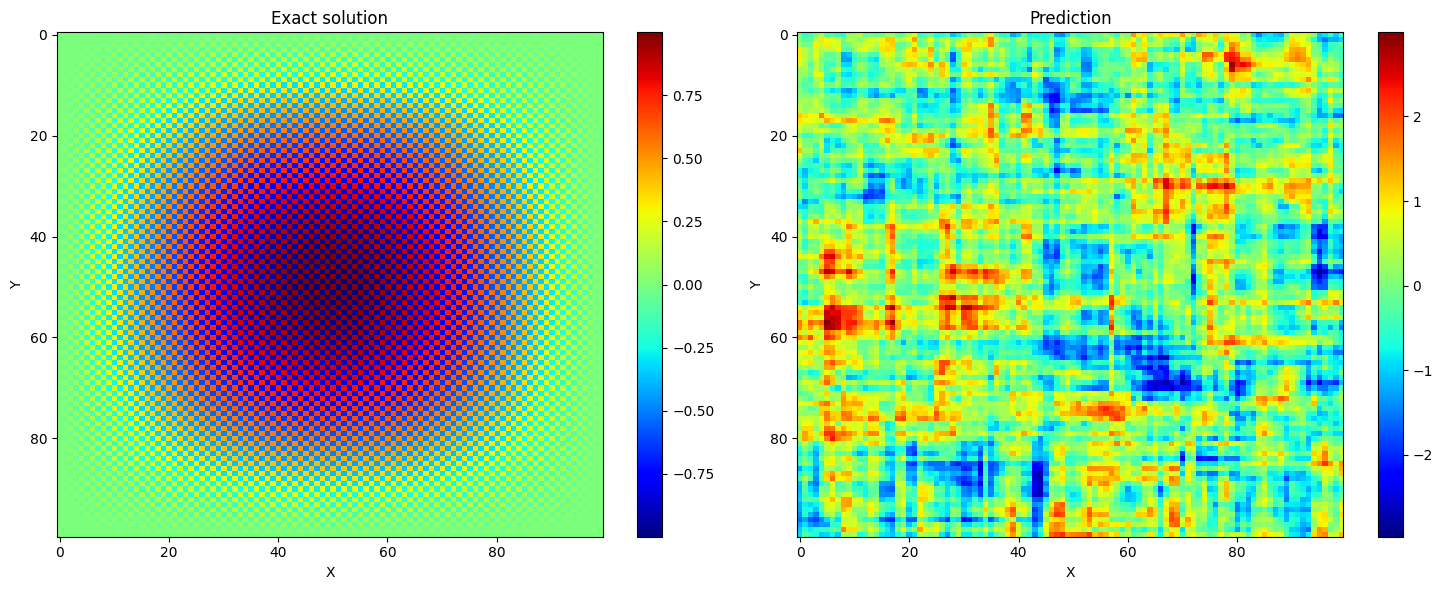

In [5]:
# Compare the exact solution and model prediction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

im1 = ax1.imshow(cube_ref, cmap='jet', aspect='auto')
ax1.set_title('Exact solution')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(cube_test, cmap='jet', aspect='auto')
ax2.set_title('Prediction')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()


In [6]:
def sample_pde_points(N_f, Xmin, Xmax, device):
    """Latin hypercube samples inside [Xmin, Xmax] and their target PDE values."""
    lhs_samples = lhs(2, N_f)
    coords = Xmin + torch.tensor(lhs_samples, dtype=torch.float32, device=device) * (Xmax - Xmin)
    targets = f_target(coords[:, 0:1], coords[:, 1:2])
    return coords, targets

def sample_boundary_points(N_b, Xmin, Xmax, device):
    """Sample N_b points on each of the four boundaries."""
    """Points on each boundary segment plus target boundary values."""
    r = torch.rand(N_b, 1, device=device)
    x_span = Xmin[0] + (Xmax[0] - Xmin[0]) * r
    y_span = Xmin[1] + (Xmax[1] - Xmin[1]) * r
    
    # Sample points on the four boundaries
    boundary = torch.cat((
        torch.cat([x_span, torch.full_like(x_span, Xmin[1])], dim=1),
        torch.cat([x_span, torch.full_like(x_span, Xmax[1])], dim=1),
        torch.cat([torch.full_like(y_span, Xmin[0]), y_span], dim=1),
        torch.cat([torch.full_like(y_span, Xmax[0]), y_span], dim=1)
    ), dim=0)
    
    targets = u_target(boundary[:, 0:1], boundary[:, 1:2])
    return boundary, targets

In [7]:
def compute_pde_loss(model, coords, target_pde, criterion):
    """Compute the PDE residual loss."""
    coords.requires_grad_(True)
    y_pred = model(coords)

    # First-order derivatives
    grad_u = torch.autograd.grad(y_pred,coords,grad_outputs=torch.ones_like(y_pred),create_graph=True,retain_graph=True)[0]

    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]

    # Second-order derivatives
    u_xx = torch.autograd.grad(u_x,coords,grad_outputs=torch.ones_like(u_x),create_graph=True,retain_graph=True)[0][:, 0:1]
    u_yy = torch.autograd.grad(u_y,coords,grad_outputs=torch.ones_like(u_y),create_graph=True,retain_graph=True)[0][:, 1:2]

    # Helmholtz operator: u_xx + u_yy + u
    pde_lhs  = u_xx + u_yy + y_pred

    return criterion(pde_lhs , target_pde)

def compute_boundary_loss(model, boundary_coords, target_boundary, criterion):
    """Compute the boundary condition loss."""
    u_pred = model(boundary_coords)

    return criterion(u_pred, target_boundary)

In [8]:
# Training configuration
batch = 10
N_f, N_b, nmax = 512 * batch, 128 * batch, 50000

criterion = nn.MSELoss()
initial_lr = 5e-4
alpha = 1e-7 / 5e-4

optimizer = torch.optim.Adam(model.parameters(),lr=initial_lr)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=nmax,eta_min=initial_lr * alpha)

# Computational domain
Xmin = torch.tensor([-1.0, -1.0], device=device)
Xmax = torch.tensor([1.0, 1.0], device=device)

loss_history = []
start_time = time.time()
start_time_record = time.time()

for n in range(nmax):

    # Resample collocation and boundary points at each iteration
    X_f, y_batch = sample_pde_points(N_f, Xmin, Xmax, device)
    boundary_sample, u_boundary = sample_boundary_points(N_b, Xmin, Xmax, device)

    optimizer.zero_grad()

    # PDE and boundary losses
    loss_pde = compute_pde_loss(model, X_f, y_batch, criterion)
    loss_boundary = compute_boundary_loss(model, boundary_sample, u_boundary, criterion)

    if n == 0:
        print(f"n: {n}, loss_boundary: {loss_boundary.item():.3e}, loss_pde: {loss_pde.item():.3e}")

    # Loss scaling used in the RepNN Helmholtz experiment
    loss = (torch.pow(loss_boundary, 1 / 3) + torch.pow(loss_pde, 1 / 3))

    loss.backward()
    optimizer.step()
    scheduler.step()

    # Report training progress every 1000 iterations
    if (n + 1) % 1000 == 0:
        elapsed = int(time.time() - start_time)
        print(f"n: {n + 1}, loss_boundary: {loss_boundary.item():.3e}, loss_pde: {loss_pde.item():.3e}, time: {elapsed}")

        loss_history.append(loss.item())
        start_time = time.time()


n: 0, loss_boundary: 5.744e-01, loss_pde: 7.183e+09
n: 1000, loss_boundary: 9.554e-03, loss_pde: 1.509e+07, time: 28
n: 2000, loss_boundary: 4.021e-03, loss_pde: 5.281e+06, time: 27
n: 3000, loss_boundary: 5.739e-04, loss_pde: 3.903e+06, time: 26
n: 4000, loss_boundary: 1.344e-04, loss_pde: 3.486e+06, time: 26
n: 5000, loss_boundary: 4.199e-04, loss_pde: 2.746e+06, time: 26
n: 6000, loss_boundary: 3.896e-04, loss_pde: 2.710e+06, time: 26
n: 7000, loss_boundary: 5.475e-04, loss_pde: 2.159e+06, time: 26
n: 8000, loss_boundary: 4.400e-04, loss_pde: 2.331e+06, time: 26
n: 9000, loss_boundary: 8.481e-04, loss_pde: 1.847e+06, time: 27
n: 10000, loss_boundary: 1.145e-04, loss_pde: 1.451e+06, time: 26
n: 11000, loss_boundary: 8.173e-04, loss_pde: 1.501e+06, time: 26
n: 12000, loss_boundary: 3.484e-04, loss_pde: 1.407e+06, time: 26
n: 13000, loss_boundary: 2.355e-04, loss_pde: 1.231e+06, time: 26
n: 14000, loss_boundary: 1.124e-03, loss_pde: 1.221e+06, time: 26
n: 15000, loss_boundary: 4.509e-0

In [9]:
start_time_record - time.time()

-1351.493782043457

In [10]:
# Evaluate the trained model on a high-resolution grid
axis = torch.linspace(-1.0, 1.0, 1000).unsqueeze(1)
X, Y = torch.meshgrid(axis.squeeze(),axis.squeeze(),indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1)],dim=1)

targets = u_target(X_star[:, 0:1],X_star[:, 1:2])

with torch.no_grad():
    y_pred = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

# Relative L2 error
err = (torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref))
print(f"Error(L2): {err:.5e}")

# Reshape predictions for visualization
cube_ref = y_ref.view(len(axis), len(axis)).cpu().numpy()
cube_test = y_test.view(len(axis), len(axis)).cpu().numpy()


Error(L2): 6.38917e-05


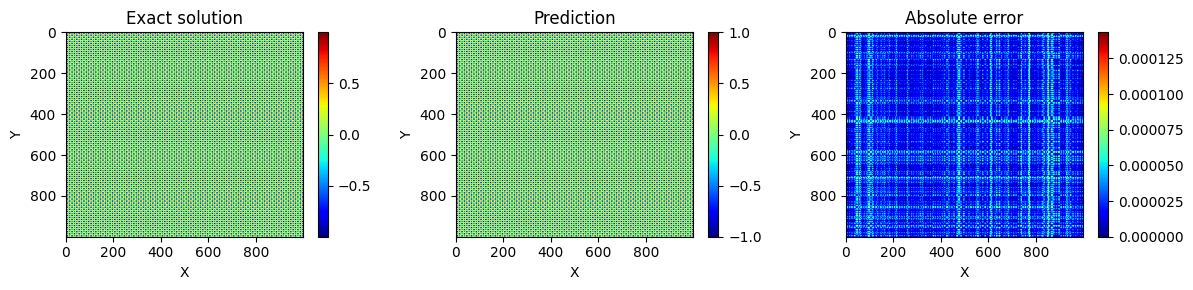

In [11]:
# Visualize the exact solution, prediction, and absolute error
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3))

im1 = ax1.imshow(cube_ref, cmap='jet', aspect='auto')
ax1.set_title('Exact solution')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(cube_test, cmap='jet', aspect='auto')
ax2.set_title('Prediction')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
plt.colorbar(im2, ax=ax2)

im3 = ax3.imshow(
    np.abs(cube_test - cube_ref),
    cmap='jet',
    aspect='auto'
)
ax3.set_title('Absolute error')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
plt.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.show()


In [12]:
# Evaluate the trained model on Latin hypercube test points
X_star = lhs(2, 10000) * 2 - 1
X_star = torch.tensor(X_star,dtype=torch.float32,device=device)

targets = u_target(X_star[:, 0:1],X_star[:, 1:2])

with torch.no_grad():
    y_pred = model(X_star)

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1)

# Relative L2 error
err = (torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref))

print(f"Error(L2): {err:.5e}")


Error(L2): 6.35970e-05


In [1]:
axis = torch.linspace(-1.0, 1.0, 1000).unsqueeze(1)
X, Y = torch.meshgrid(axis.squeeze(), axis.squeeze(), indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

targets = u_target(X_star[:, 0:1], X_star[:, 1:2])

with torch.no_grad():
    y_pred, _ = model(X_star.to(device))

y_test = y_pred.view(-1, 1).cpu().numpy()
y_ref = targets.view(-1, 1).to(device).cpu().numpy()

scipy.io.savemat("y_pre.mat", {'u': y_test}) 
scipy.io.savemat("y_ref.mat", {'u': y_ref}) 

NameError: name 'torch' is not defined